In [1]:
import numpy as tnp

import matplotlib.pyplot as plt
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus,
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    circle,
    spider,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation


%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
!nvidia-smi

Fri Feb 20 16:45:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             63W /  300W |   19236MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## num stars trade

In [3]:
npix_pupil = 256
d_pupil = 3000
dx_pupil = d_pupil / npix_pupil
fno = 15
efl = d_pupil * fno
wvl = 0.633
npix_focal = 128
dx_focal = 9.5 # 3.76

x, y = make_xy_grid(shape=npix_pupil, diameter=d_pupil)
r, t = cart_to_polar(x, y)
r_norm = r / (d_pupil / 2)

A = circle(radius=d_pupil / 2, r=r)
A = A / np.sqrt(A.sum())

nms = [noll_to_nm(i) for i in range(1, 37)]
zernikes = np.array(zernike_nm_seq(nms, r_norm, t, norm=True))
# zernikes = np.array([z / np.max(np.abs(z)) for z in zernikes])

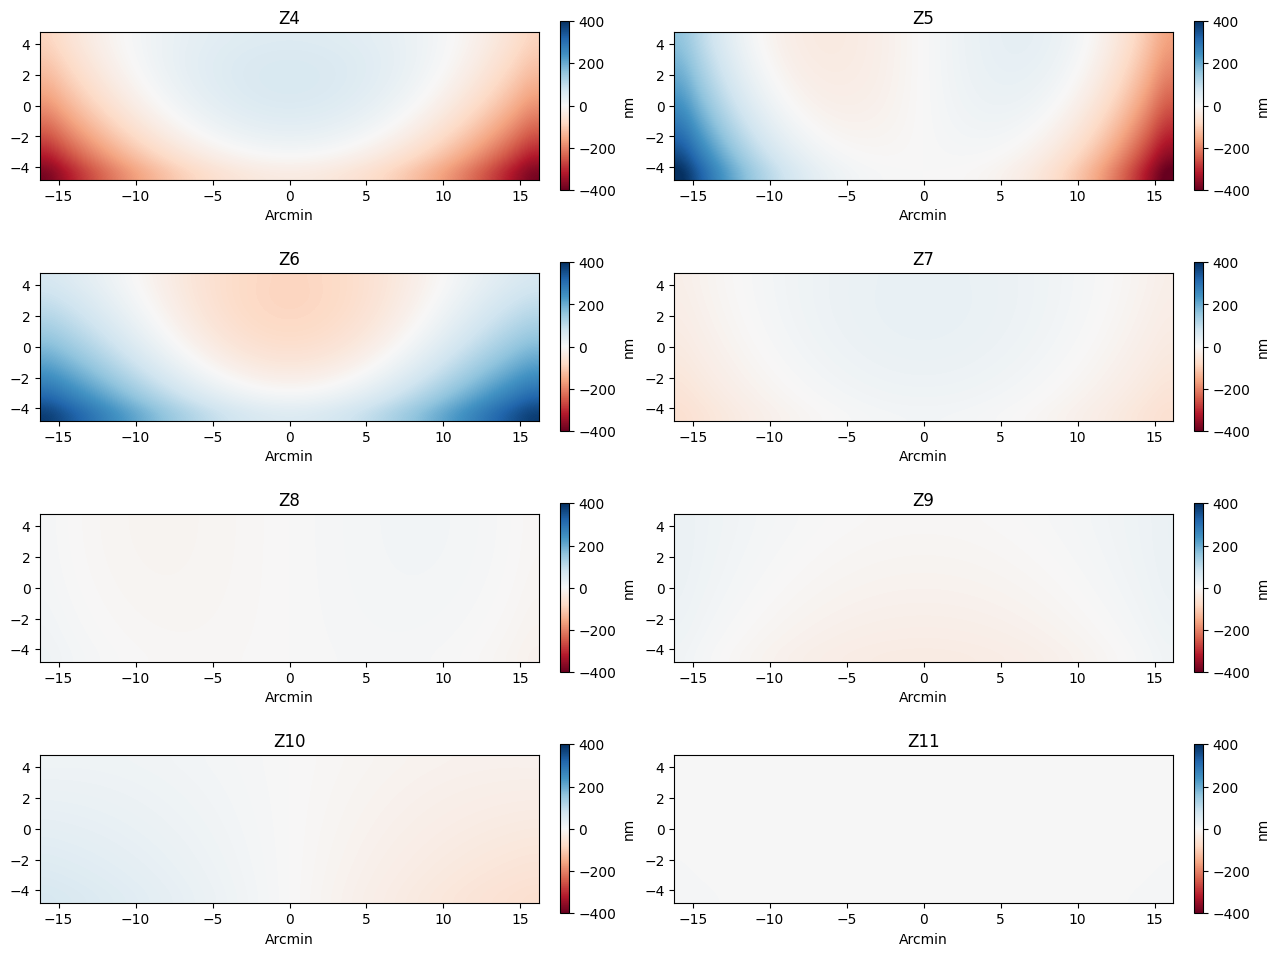

In [4]:
raytrace = Lazuli_stop()

# indices for the zernikes which exhibit field dependence that changes with alignment: Z4 - Z11
# THESE DO NOT CORRESPOND TO NOLL INDICES
inds = [i + 3 for i in range(8)]

# field positions to evaluate
fields_x = np.linspace(-16.2, 16.2, 33) / 60 # +/- 16.2 arcmin in x
fields_y = np.linspace(-4.8, 4.8, 11) / 60  # +/- 4.8 arcmin in y

# initialize array to hold coeffs for field-dependent zernikes at nominal alignment
field_coeffs_nom = np.zeros((len(inds), len(fields_x), len(fields_y)))

# loop through fields
for i, field_x in enumerate(fields_x):
    for j, field_y in enumerate(fields_y):
        
        # get raytrace OPD at field point
        ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=A.shape[0])
        opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * wvl * 1e3
        opd[~A.astype(bool)] = np.nan

        # decompose
        field_coeffs_nom[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

# create interpolators for field-dependent zernikes
field_interps_nom = [interpolate.RegularGridInterpolator((fields_x, fields_y), field_coeffs_nom[i, :, :], method='cubic') for i in range(field_coeffs_nom.shape[0])]

# show field dependence for field-dependent zernikes
plt.figure(figsize=(15, 12))
for i in range(field_coeffs_nom.shape[0]):
    plt.subplot(4, 2, i + 1)
    plt.title(f'Z{i + 4:.0f}')
    plt.imshow(field_coeffs_nom[i, :, :].get().T, interpolation='bicubic', extent=[-16.2, 16.2, -4.8, 4.8], vmin=-400, vmax=400, cmap='RdBu')
    plt.xlabel('Arcmin')
    plt.colorbar(fraction=0.016, pad=0.04, label='nm')

In [ ]:
n_stars_range = np.linspace(1, 20, 20)

n_photons = 150000
opd_rms = 250
samples_stars = 10
samples_opds = 10

cr_bounds = np.zeros(len(n_stars_range))

for n, n_stars in enumerate(n_stars_range):

    n_stars = int(n_stars)

    print(str(n_stars) + ' star case...')

    cr_bound = 0

    for i in range(samples_stars):

        positions_x = np.random.uniform(low=-16.2 / 60, high=16.2 / 60, size=n_stars)
        positions_y = np.random.uniform(low=-4.8 / 60, high=4.8 / 60, size=n_stars)
        positions = [(float(x), float(y)) for x, y in zip(positions_x, positions_y)]

        coeffs_field = [[interp(np.array(position)) for interp in field_interps_nom] for position in positions]

        for j in range(samples_opds):

            coeffs_opd = np.random.normal(loc=0, size=len(zernikes[inds]))
            opd = sum_of_2d_modes(zernikes[inds], coeffs_opd)
            opd *= opd_rms / np.sqrt(np.mean(opd[A.astype('bool')] ** 2))

            deltas = [sum_of_2d_modes(modes=zernikes[inds], weights=np.array(coeffs)).squeeze() for coeffs in coeffs_field]

            phis = [(2 * np.pi / wvl) * (opd + delta) for delta in deltas]

            gs = [A * np.exp(1j * phi) for phi in phis]

            Gs = [focus_fixed_sampling(wavefunction=g, input_dx=dx_pupil, prop_dist=efl, wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal) for g in gs]

            Is = [np.abs(G) ** 2 for G in Gs]

            fisher_matrix = np.zeros((len(zernikes[inds]), len(zernikes[inds])))

            for g, G, I in zip(gs, Gs, Is):

                p1 = np.zeros((len(zernikes[inds]), npix_focal ** 2))

                for k in range(len(zernikes[inds])):

                    p1[k, :] = (np.conj(G) * focus_fixed_sampling(wavefunction=g * zernikes[inds][k], input_dx=dx_pupil, prop_dist=efl, 
                                                                        wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal)).imag.ravel()

                p2 = p1[None, :, :] * p1[:, None, :]

                p3 = p2 * n_photons * 4 / I.ravel()[None, None, :]

                fisher_matrix += np.sum(p3, axis=2)

            cov_matrix = np.linalg.inv(fisher_matrix)
        
            cr_bound += np.trace(cov_matrix) / (samples_opds * samples_stars)
    
    cr_bounds[n] = cr_bound

1 star case...
2 star case...
3 star case...
4 star case...
5 star case...
6 star case...
7 star case...
8 star case...
9 star case...
10 star case...
11 star case...
12 star case...
13 star case...
14 star case...
15 star case...
16 star case...
17 star case...
18 star case...
19 star case...
20 star case...


In [7]:
cr_bounds[0]

array(0.00165279)

Text(0.5, 1.0, '10e3 Photons per Image, 10 nm RMS OPD')

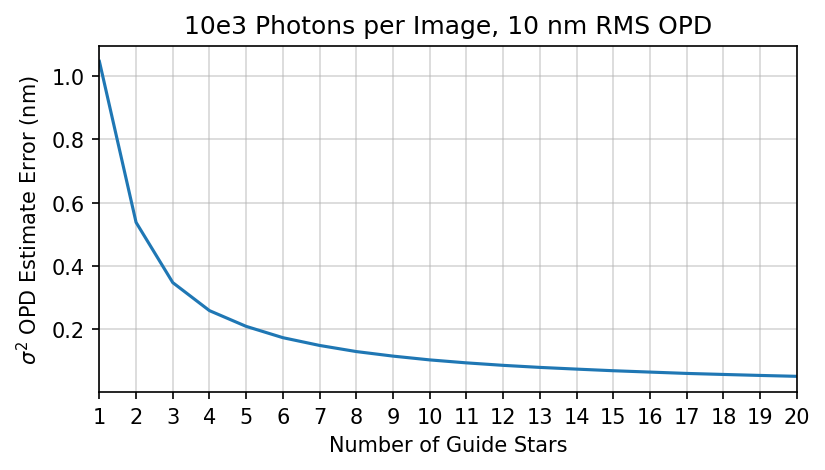

In [ ]:
# 10 x 10 samples

plt.figure(figsize=(6, 3), dpi=150)
plt.plot(n_stars_range.get(), cr_bounds.get() * 633)
plt.xlabel('Number of Guide Stars')
plt.xticks(range(1, 21))
plt.xlim([1, 20])
plt.ylabel('$\sigma^2$ OPD Estimate Error (nm)')
# plt.yticks(range(10, 101, 10))
plt.grid(alpha=0.5)
plt.title('150,000 Photons per Image, 250 nm RMS OPD')

Text(0.5, 1.0, '100 Photons per Image, 100 nm RMS OPD')

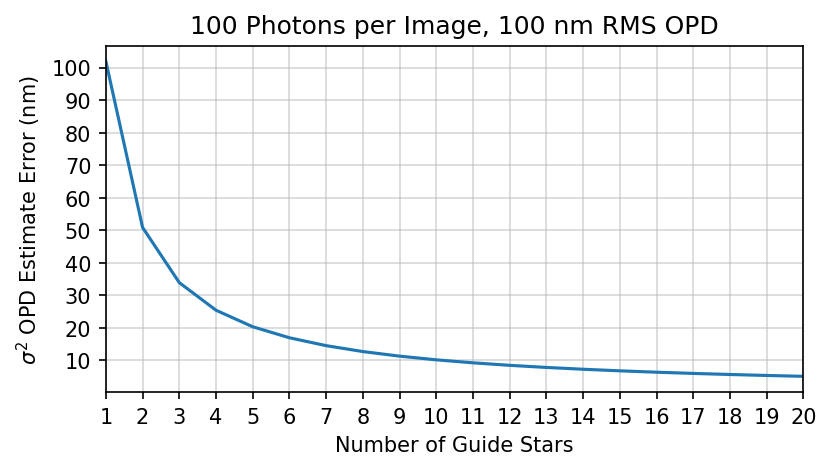

In [ ]:
# 50 x 50 samples

plt.figure(figsize=(6, 3), dpi=150)
plt.plot(n_stars_range.get(), cr_bounds.get() * 633)
plt.xlabel('Number of Guide Stars')
plt.xticks(range(1, 21))
plt.xlim([1, 20])
plt.ylabel('$\sigma^2$ OPD Estimate Error (nm)')
plt.yticks(range(10, 101, 10))
plt.grid(alpha=0.5)
plt.title('100 Photons per Image, 100 nm RMS OPD')

## diversity trade

In [4]:
def calc_cr_bounds(samples, fx_diversity, n_photons, coeff_diversities, opd_rms_vals):

    cr_bounds = np.zeros((len(coeff_diversities), len(opd_rms_vals)))

    for t, opd_rms in enumerate(opd_rms_vals):

        for s, coeff_diversity in enumerate(coeff_diversities):

            coeffs_diversity = [0, coeff_diversity]

            for i in range(samples):

                coeffs_opd = np.random.normal(loc=0, size=len(zernikes))

                opd = sum_of_2d_modes(zernikes, coeffs_opd)
                
                opd *= opd_rms / np.sqrt(np.mean(opd[A.astype('bool')] ** 2))

                deltas = [fx_diversity * wvl * coeff for coeff in coeffs_diversity]

                phis = [(2 * np.pi / wvl) * (opd + delta) for delta in deltas]

                gs = [A * np.exp(1j * phi) for phi in phis]

                Gs = [focus_fixed_sampling(wavefunction=g, input_dx=dx_pupil, prop_dist=efl, wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal) for g in gs]

                Is = [np.abs(G) ** 2 for G in Gs]

                fisher_matrix = np.zeros((len(zernikes), len(zernikes)))

                for g, G, I in zip(gs, Gs, Is):

                    p1 = np.zeros((len(zernikes), npix_focal ** 2))

                    for j in range(len(zernikes)):

                        p1[j, :] = (np.conj(G) * focus_fixed_sampling(wavefunction=g * zernikes[j], input_dx=dx_pupil, prop_dist=efl, 
                                                                            wavelength=wvl, output_dx=dx_focal, output_samples=npix_focal)).imag.ravel()

                    p2 = p1[None, :, :] * p1[:, None, :]

                    p3 = p2 * n_photons * 4 / I.ravel()[None, None, :]

                    fisher_matrix += np.sum(p3, axis=2)

                cov_matrix = np.linalg.inv(fisher_matrix)
            
                cr_bound = np.trace(cov_matrix)

                cr_bounds[s, t] += cr_bound / samples

    return cr_bounds

In [ ]:
npix_pupil = 256
d_pupil = 3000
dx_pupil = d_pupil / npix_pupil
fno = 15
efl = d_pupil * fno
wvl = 0.633
npix_focal = 128
dx_focal = 9.5 # 3.76

x, y = make_xy_grid(shape=npix_pupil, diameter=d_pupil)
r, t = cart_to_polar(x, y)
r_norm = r / (d_pupil / 2)

A = circle(radius=d_pupil / 2, r=r)
A = A / np.sqrt(A.sum())

nms = [noll_to_nm(i) for i in range(4, 12)]
zernikes = np.array(zernike_nm_seq(nms, r_norm, t, norm=True))
# zernikes = np.array([z / np.max(np.abs(z)) for z in zernikes])

Text(0, 0.5, 'RMS Diversity (Waves)')

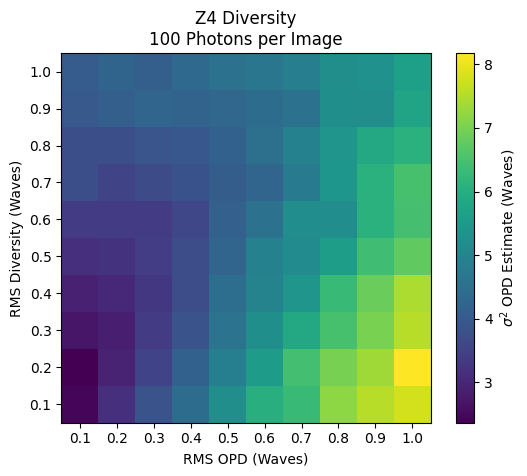

In [57]:
samples = 100
fx_diversity = zernikes[0]
n_photons = 1

coeff_diversities = np.linspace(0.1, 1, 10)
opd_rms_vals = np.linspace(wvl / 10, wvl, 10) 


cr_bounds = calc_cr_bounds(samples=samples, fx_diversity=zernikes[0], n_photons=n_photons, coeff_diversities=coeff_diversities, opd_rms_vals=opd_rms_vals)

plt.figure()
plt.title('Z4 Diversity\n100 Photons per Image')
plt.imshow(cr_bounds.get(), origin='lower')
plt.colorbar(label='$\sigma^2$ OPD Estimate (Waves)')

plt.xticks(range(cr_bounds.shape[1]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
plt.xlabel('RMS OPD (Waves)')

plt.yticks(range(cr_bounds.shape[0]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
plt.ylabel('RMS Diversity (Waves)')

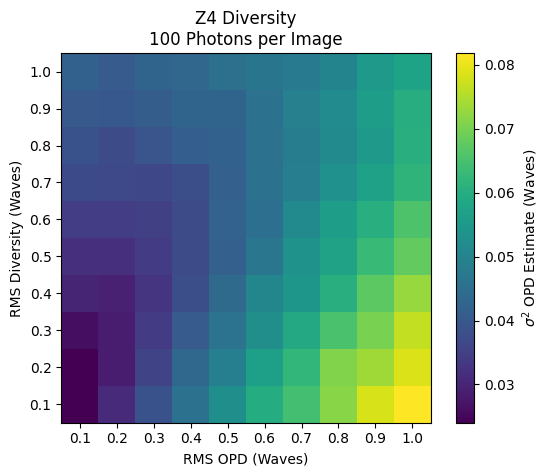

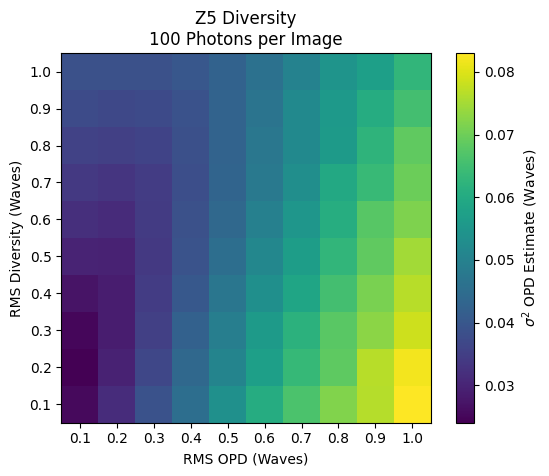

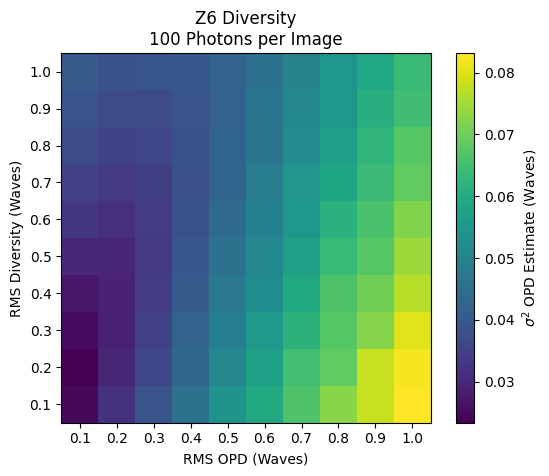

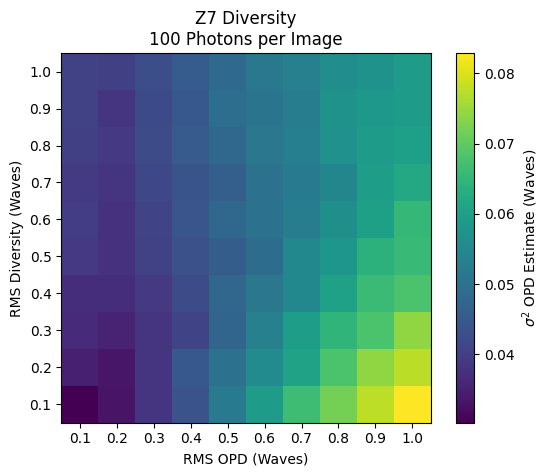

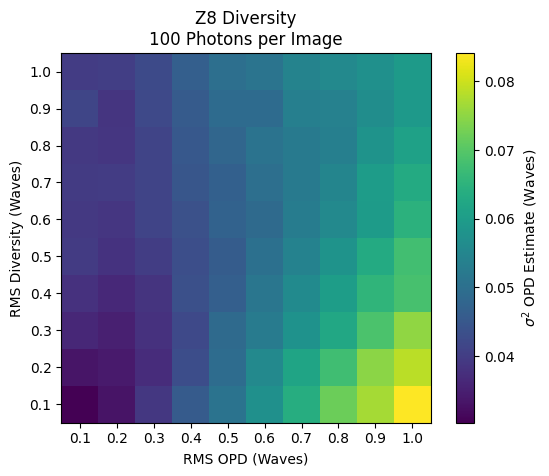

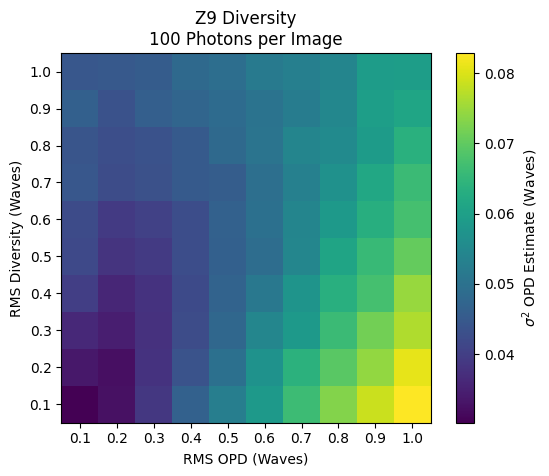

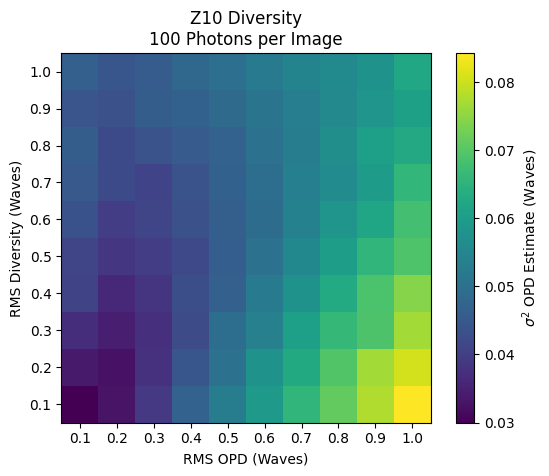

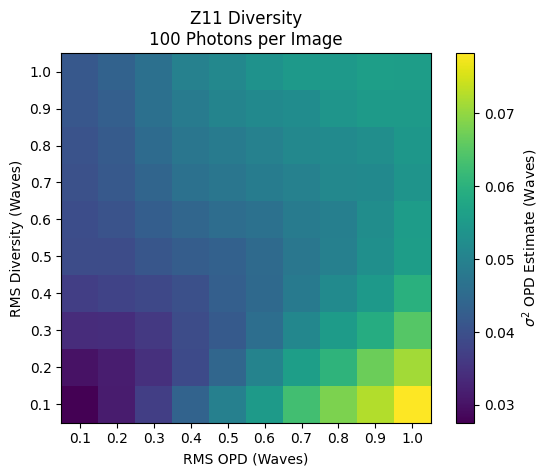

In [5]:
samples = 500
fx_diversity = zernikes[0]
n_photons = 100

coeff_diversities = np.linspace(0.1, 1, 10)
opd_rms_vals = np.linspace(wvl / 10, wvl, 10) 

for i, fx_diversity in enumerate(zernikes):

    print('Z' + str(i + 4) + ' evaluation', end='\r')

    cr_bounds = calc_cr_bounds(samples=samples, fx_diversity=fx_diversity, n_photons=n_photons, coeff_diversities=coeff_diversities, opd_rms_vals=opd_rms_vals)

    plt.figure()
    plt.title('Z' + str(i + 4) + ' Diversity\n100 Photons per Image')
    plt.imshow(cr_bounds.get(), origin='lower')
    plt.colorbar(label='$\sigma^2$ OPD Estimate (Waves)')

    plt.xticks(range(cr_bounds.shape[1]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
    plt.xlabel('RMS OPD (Waves)')

    plt.yticks(range(cr_bounds.shape[0]), [f'{num:0.1f}' for num in np.linspace(0.1, 1, 10)])
    plt.ylabel('RMS Diversity (Waves)')

Text(0.5, 1.0, '2 images: 2 symmetric defocus\n1 photon per image')

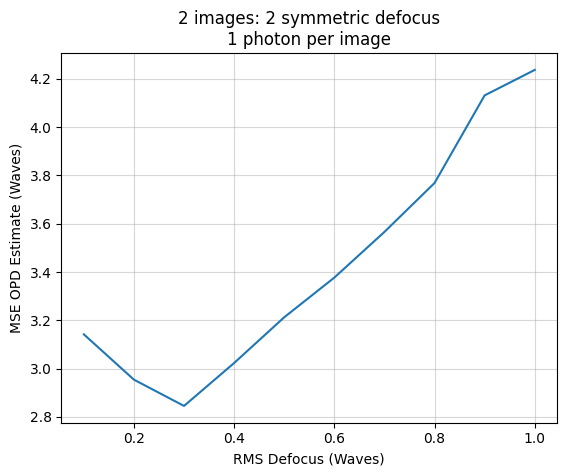

In [58]:
plt.plot(coeff_diversities.get(), cr_bounds[:, 1].get())
plt.xlabel('RMS Defocus (Waves)')
plt.ylabel('MSE OPD Estimate (Waves)')
plt.grid(alpha=0.5)
plt.title('2 images: 2 symmetric defocus\n1 photon per image')

Text(0.5, 1.0, '3.58')

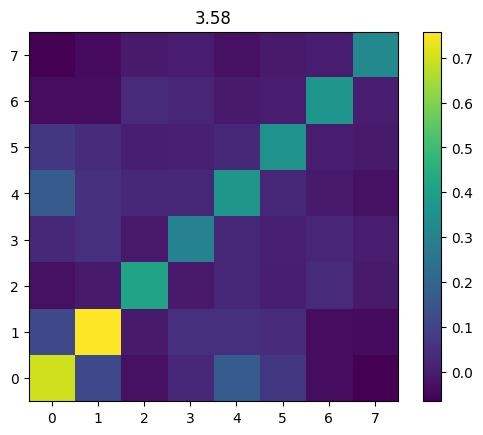

In [69]:
plt.imshow(cov_matrix.get(), origin='lower')
plt.colorbar()
plt.title(f'{cr_bound:.2f}')

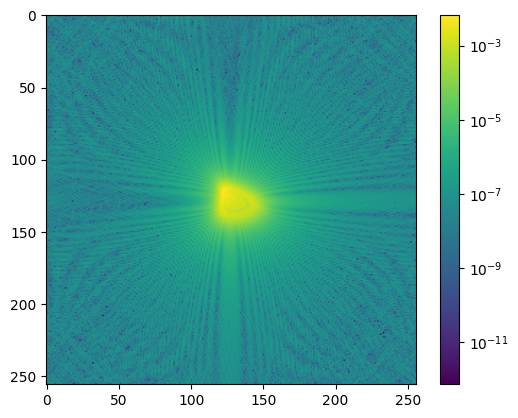

In [72]:
data = Is[1]
mask = A.astype('bool')

plt.imshow(data.get(), norm='log')
plt.colorbar()
# plt.title(f'{np.sum(data):.6f} sum\n{np.sqrt(np.mean(data[mask] ** 2)):.6f} rms')

Text(0.5, 1.0, '37841.846044 sum\n0.999211 rms')

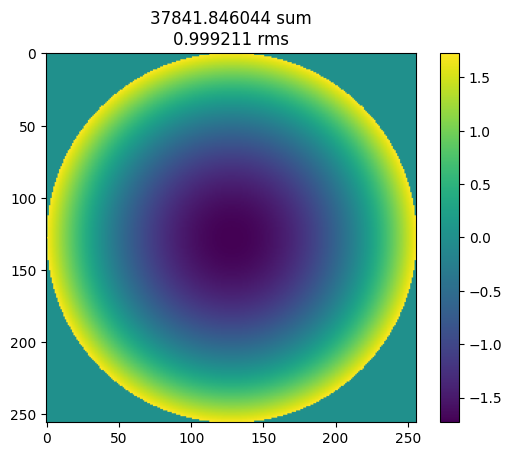

In [25]:
data = zernikes[0]
mask = A.astype('bool')

plt.imshow(data.get() * mask.get())
plt.colorbar()
plt.title(f'{np.sum(data):.6f} sum\n{np.sqrt(np.mean(data[mask] ** 2)):.6f} rms')